Prueba

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.2/934.2 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.5/890.5 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.6 MB/s eta 0:00:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts.models import TFTModel
from darts import TimeSeries
import torch
import pytorch_lightning as pl
#from darts.datasets import AirPassengersDataset

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
np.random.seed(42)


LEER DATASET

In [ ]:
import pandas as pd

datos = pd.read_csv("/content/drive/MyDrive/transformers/SNpollutionFinal.csv")

datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [ ]:
datos.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2010-01-01 00:00:00,129.0,-21,-11.0,1021.0,2,1.79
2010-01-01 01:00:00,129.0,-21,-12.0,1020.0,2,4.92
2010-01-01 02:00:00,129.0,-21,-11.0,1019.0,2,6.71
2010-01-01 03:00:00,129.0,-21,-14.0,1019.0,2,9.84
2010-01-01 04:00:00,129.0,-20,-12.0,1018.0,2,12.97


In [ ]:
datos = datos.drop(datos.index[:24])

datos

,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,1,1.79
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,1,2.68
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,1,3.57
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,1,5.36
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,1,6.25
...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,2,231.97
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,2,237.78
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,2,242.70


In [ ]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


Se divide el dataset

In [ ]:
# Dividir el conjunto de datos en entrenamiento y prueba
train, test = train_test_split(datos, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
test, val = train_test_split(test, test_size=0.33, shuffle=False)

print("Las dimensiones de train son: ", train.shape)
print("Las dimensiones de test son: ", test.shape)
print("Las dimensiones de val son: ", val.shape)

Las dimensiones de train son:  (30660, 6)
Las dimensiones de test son:  (8803, 6)
Las dimensiones de val son:  (4337, 6)


Se normalizan los datos

In [ ]:
from sklearn.preprocessing import StandardScaler


# Normalizar solo con los datos de entrenamiento
scaler = StandardScaler()
train = scaler.fit_transform(train)

# Aplicar la transformación a test y val usando los parámetros de train
test = scaler.transform(test)
val = scaler.transform(val)

train = pd.DataFrame(train, columns=datos.columns)
test = pd.DataFrame(test, columns=datos.columns)
val = pd.DataFrame(val, columns=datos.columns)


Se unen los datos nuevamente, ahora normalizados, en un único conjunto.

In [ ]:
datosNormalizados = pd.concat([train, test, val])

datosNormalizados.index = datos.index


In [ ]:
datosNormalizados.shape

(43800, 6)

In [ ]:
datosNormalizados.head(13)


,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2010-01-02 00:00:00,0.317681,-1.214023,-1.268524,0.329687,-0.380944,-0.464048
2010-01-02 01:00:00,0.526152,-1.144302,-1.268524,0.329687,-0.380944,-0.446575
2010-01-02 02:00:00,0.646846,-0.865419,-1.349314,0.426127,-0.380944,-0.429103
2010-01-02 03:00:00,0.888234,-0.586536,-1.349314,0.522567,-0.380944,-0.393962
2010-01-02 04:00:00,0.416431,-0.586536,-1.349314,0.522567,-0.380944,-0.376489
2010-01-02 05:00:00,0.098238,-0.586536,-1.430104,0.522567,-0.380944,-0.359017
2010-01-02 06:00:00,0.054349,-0.586536,-1.430104,0.619008,-0.380944,-0.323876
2010-01-02 07:00:00,0.262820,-0.586536,-1.349314,0.715448,-0.380944,-0.288735
2010-01-02 08:00:00,0.218931,-0.656257,-1.430104,0.715448,-0.380944,-0.253594


In [ ]:
pasados = 12

In [ ]:
serie = TimeSeries.from_dataframe(datosNormalizados)

print(serie)

<TimeSeries (DataArray) (date: 43800, component: 6, sample: 1)> Size: 2MB
array([[[ 0.31768099],
        [-1.2140229 ],
        [-1.26852411],
        [ 0.32968671],
        [-0.38094383],
        [-0.46404777]],

       [[ 0.52615226],
        [-1.14430217],
        [-1.26852411],
        [ 0.32968671],
        [-0.38094383],
        [-0.44657536]],

       [[ 0.64684616],
        [-0.86541928],
        [-1.34931411],
        [ 0.42612698],
        [-0.38094383],
        [-0.42910295]],
...
       [[-0.98800754],
        [-1.63234723],
        [-1.18773412],
        [ 1.67985054],
        [ 0.69453847],
        [ 4.26547885]],

       [[-1.00995189],
        [-1.63234723],
        [-1.26852411],
        [ 1.67985054],
        [ 0.69453847],
        [ 4.34439918]],

       [[-0.9660632 ],
        [-1.56262651],
        [-1.18773412],
        [ 1.67985054],
        [ 0.69453847],
        [ 4.4058471 ]]])
Coordinates:
  * date       (date) datetime64[ns] 350kB 2010-01-02 ... 2014-12-31T2

In [ ]:
Y = serie["pollution"]
X = serie.drop_columns("pollution")


trainX, testX = X.split_after(0.7)
testX, valX = testX.split_after(0.66)

print(len(trainX))
print(len(testX))
print(len(valX))

30660
8672
4468


30660
8672
4468


<Axes: xlabel='date'>

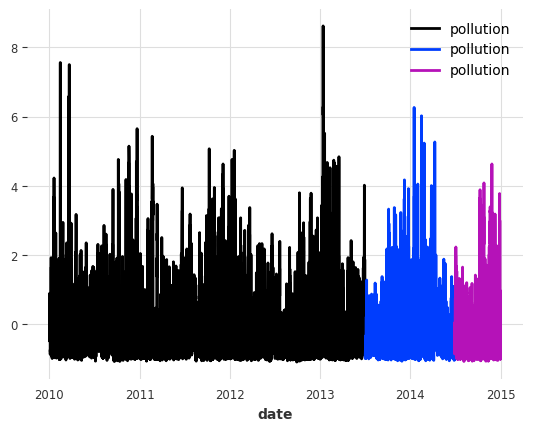

In [ ]:
trainY, testY = Y.split_after(0.7)
testY, valY = testY.split_after(0.66)

print(len(trainY))
print(len(testY))
print(len(valY))

trainY.plot()
testY.plot()
valY.plot()

In [ ]:
futuros=0

In [ ]:
import pytorch_lightning as pl

# Fijar la semilla para la reproducibilidad
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [ ]:
import logging
log = logging.getLogger("pytorch_lightning")
log.propagate = False
log.setLevel(logging.ERROR)

In [ ]:
from pytorch_lightning.callbacks import Callback

class LossRecorder(Callback):
    def __init__(self):
        self.train_loss_history = []
        self.val_loss_history = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss_history.append(trainer.callback_metrics["train_loss"].item())
        self.val_loss_history.append(trainer.callback_metrics["val_loss"].item())

In [ ]:
params = {'batch_size': 32, 'dropout': 0.2, 'hidden_continuous_size': 16, 'hidden_size': 64, 'learning_rate': 1.4106695091696454e-05, 'lstm_layers': 1.0, 'num_attention_heads': 2}

early_stopper = pl.callbacks.EarlyStopping(
monitor="val_loss",
patience=15,
min_delta=0,
mode='min',
verbose = True
)

loss_recorder = LossRecorder()

my_model = TFTModel(
    input_chunk_length=pasados,
    output_chunk_length=1,
    hidden_size=int(params["hidden_size"]),
    dropout=float(params["dropout"]),
    batch_size=int(params["batch_size"]),
    n_epochs=128,
    optimizer_kwargs={"lr": float(params["learning_rate"])},
    random_state=42,
    add_relative_index= True,
    loss_fn=torch.nn.MSELoss(),
    likelihood=None,
    output_chunk_shift = futuros,
    save_checkpoints = True,
    use_static_covariates = False,
    lstm_layers = int(params["lstm_layers"]),
    hidden_continuous_size = int(params["hidden_continuous_size"]),
    num_attention_heads = int(params["num_attention_heads"]),
    pl_trainer_kwargs= {"callbacks": [early_stopper, loss_recorder],
                        "accelerator": "gpu",  
                        "devices": "auto"}
)
my_model.fit(
    series=trainY,
    val_series=testY,
    past_covariates=trainX,
    val_past_covariates=testX,
    verbose=True
)
my_model = TFTModel.load_from_checkpoint(model_name=my_model.model_name, best=True)



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/darts/models/forecasting/torch_forecasting_model.py:1842: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: TorchForecastingModel 

In [ ]:
# Crear todas las ventanas de 12 pasos
windowed_target_series = [valY[i:i + 12] for i in range(0, len(valY) - 12)]
windowed_covariates_series = [valX[i:i + 12] for i in range(0, len(valX) - 12)]
batch_size = 32
all_predictions = []
# Dividimos las ventanas en lotes (batches)
for i in range(0, len(windowed_target_series), batch_size):
    batch_target_windows = windowed_target_series[i:i + batch_size]
    batch_covariates_windows = windowed_covariates_series[i:i + batch_size]

    # Hacer la predicción para este lote de ventanas
    predictions = my_model.predict(
        n=1,  # Predecir solo un valor futuro para cada ventana
        series=batch_target_windows,  # Ventanas de la serie target
        past_covariates=batch_covariates_windows,  # Ventanas de las covariantes
        batch_size=batch_size,  # Tamaño del batch
        verbose=False
    )
    for pred in predictions:
        all_predictions.extend(pred.values())

preds = np.array(all_predictions)


trues = np.array(valY[pasados+futuros:].values())
if len(trues) > len(preds):
  trues = trues[:len(preds)]
else:
    preds = preds[:len(trues)]


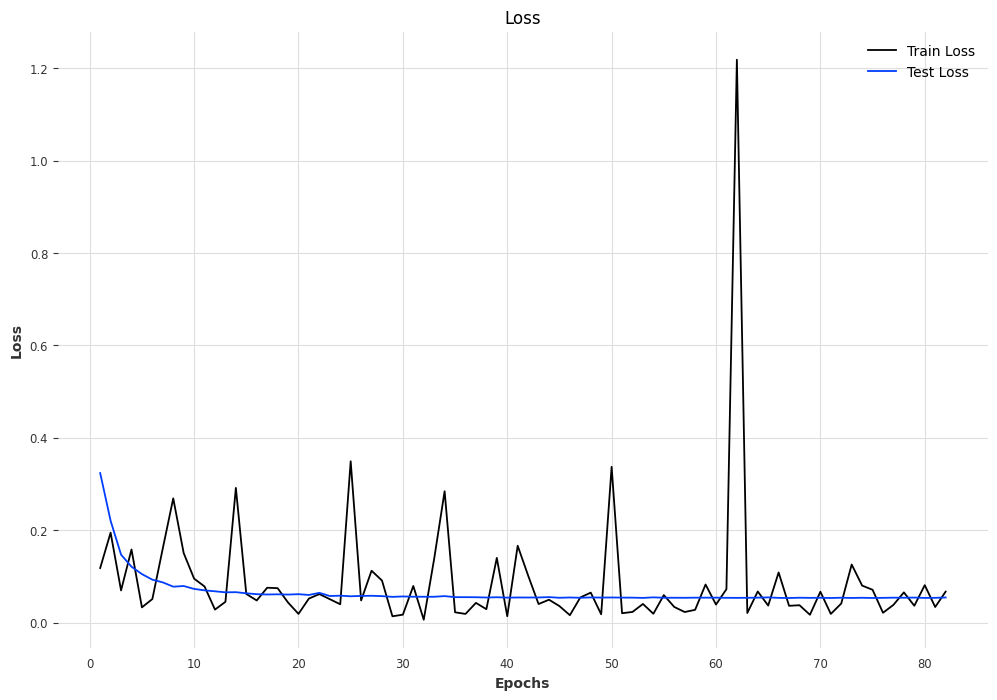

In [ ]:
ejeXTFT = range(1, len(loss_recorder.train_loss_history) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXTFT, loss_recorder.train_loss_history, label='Train Loss')
plt.plot(ejeXTFT, loss_recorder.val_loss_history, label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [ ]:
# Calcular MSE
mse = mean_squared_error(trues, preds)

# Calcular RMSE
rmse_value = rmse(trues, preds)

# Calcular MAE
mae = mean_absolute_error(trues, preds)

smape_value = smape(trues, preds)

ia_value = ia(trues, preds)


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.037363295300537815
RMSE: 0.19329587502204443
MAE: 0.11386401023656346
SMAPE: 0.31337931183289286
IA: 0.9217595768792942


In [ ]:
from datetime import timedelta

# Fecha y hora de término del conjunto de datos de prueba
end_date = datosNormalizados.index[-1]
n_observations = len(valY)

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(hours=(n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='H')

val_date = val_date[pasados+futuros:]

<ipython-input-27-f202fb545567>:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='H')


In [ ]:
print(len(valY))

4468


In [ ]:
datosNormalizados.tail(2)

,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': trues.flatten(), 'Predichos': preds.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))

fig.show()

In [ ]:
df.to_csv("/content/drive/MyDrive/transformers/errores/1paso/tftPollution.csv", index=True)

In [ ]:
# Crear todas las ventanas de 12 pasos
windowed_target_series = [Y[i:i + 12] for i in range(0, len(Y) - 12)]
windowed_covariates_series = [X[i:i + 12] for i in range(0, len(X) - 12)]
batch_size = 32
final_predictions = []
# Dividimos las ventanas en lotes (batches)
for i in range(0, len(windowed_target_series), batch_size):
    batch_target_windows = windowed_target_series[i:i + batch_size]
    batch_covariates_windows = windowed_covariates_series[i:i + batch_size]

    # Hacer la predicción para este lote de ventanas
    predictions = my_model.predict(
        n=1,  # Predecir solo un valor futuro para cada ventana
        series=batch_target_windows,  # Ventanas de la serie target
        past_covariates=batch_covariates_windows,  # Ventanas de las covariantes
        batch_size=batch_size,  # Tamaño del batch
        verbose=False
    )
    for pred in predictions:
        final_predictions.extend(pred.values())

final_predictions = np.array(final_predictions)




In [ ]:
final_predictions.shape

(43788, 1)

In [ ]:
futuros

0

In [ ]:
final_predictions2 = final_predictions


In [ ]:
final_predictions2

array([[ 0.62455741],
       [ 0.51438926],
       [ 0.77302425],
       ...,
       [-0.98087538],
       [-0.97929413],
       [-0.99145757]])

In [ ]:
print(len(final_predictions2))

43788


In [ ]:
trues2 = np.array(Y[pasados+futuros:].values())

In [ ]:
nans_start = np.full(pasados+futuros, np.nan)
nan_end = np.array([np.nan])
error = trues2 - final_predictions2

e = np.concatenate((nans_start, np.squeeze(error)))

In [ ]:
df3 = datosNormalizados.reset_index()

In [ ]:
df3["error"] = e

In [ ]:
df3.tail(15)

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,error
43785,2014-12-31 09:00:00,-1.009952,-1.632347,-1.187734,1.679851,0.694538,2.563195,-0.010671
43786,2014-12-31 10:00:00,-1.020924,-1.632347,-1.106944,1.679851,0.694538,2.703563,-0.020500
43787,2014-12-31 11:00:00,-0.966063,-1.632347,-1.106944,1.679851,0.694538,2.843931,0.040969
43788,2014-12-31 12:00:00,-0.911202,-1.632347,-0.945364,1.583410,0.694538,2.984300,0.063458
43789,2014-12-31 13:00:00,-0.977035,-1.980951,-0.945364,1.486970,0.694538,3.159809,-0.041534
43790,2014-12-31 14:00:00,-0.998980,-1.980951,-0.864574,1.486970,0.694538,3.352791,-0.026881
43791,2014-12-31 15:00:00,-0.977035,-1.911230,-0.864574,1.486970,0.694538,3.528300,0.011481
43792,2014-12-31 16:00:00,-1.009952,-1.702068,-0.945364,1.486970,0.694538,3.703810,-0.032852
43793,2014-12-31 17:00:00,-0.998980,-1.632347,-1.026154,1.583410,0.694538,3.844178,-0.004084
43794,2014-12-31 18:00:00,-0.988008,-1.632347,-1.106944,1.583410,0.694538,3.940767,0.001317


In [ ]:
df3.head(40)

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,error
0,2010-01-02 00:00:00,0.317681,-1.214023,-1.268524,0.329687,-0.380944,-0.464048,NaN
1,2010-01-02 01:00:00,0.526152,-1.144302,-1.268524,0.329687,-0.380944,-0.446575,NaN
2,2010-01-02 02:00:00,0.646846,-0.865419,-1.349314,0.426127,-0.380944,-0.429103,NaN
3,2010-01-02 03:00:00,0.888234,-0.586536,-1.349314,0.522567,-0.380944,-0.393962,NaN
4,2010-01-02 04:00:00,0.416431,-0.586536,-1.349314,0.522567,-0.380944,-0.376489,NaN
5,2010-01-02 05:00:00,0.098238,-0.586536,-1.430104,0.522567,-0.380944,-0.359017,NaN
6,2010-01-02 06:00:00,0.054349,-0.586536,-1.430104,0.619008,-0.380944,-0.323876,NaN
7,2010-01-02 07:00:00,0.262820,-0.586536,-1.349314,0.715448,-0.380944,-0.288735,NaN
8,2010-01-02 08:00:00,0.218931,-0.656257,-1.430104,0.715448,-0.380944,-0.253594,NaN
9,2010-01-02 09:00:00,0.350598,-0.586536,-1.349314,0.811888,-0.380944,-0.218452,NaN


In [ ]:
df3.to_csv("/content/drive/MyDrive/transformers/datosNarmax/1_pollution_tft", index=True)

In [ ]:
model_save_path = '/content/drive/My Drive/transformers/modelosEntrenados/NARX/1_pollution_tft.pt'
my_model.save(model_save_path)